In [21]:
import pandas as pd

# --- Load data ---
df = pd.read_csv(r"C:\Users\tkx1376\Downloads\EdU_Concat_withAssociationData_reformat4Plotting_v1.csv")

# --- Define cluster size bins ---
bins = [0, 80, 120, float('inf')]
labels = ['Small', 'Medium', 'Large']

# --- Function to count clusters per size category ---
def count_clusters(df, size_col):
    # Bin the cluster sizes
    size_category = pd.cut(df[size_col], bins=bins, labels=labels, right=False)
    
    # Count number of clusters per category
    counts = size_category.value_counts().reindex(labels, fill_value=0)
    return counts

# --- Example usage ---
control_counts = count_clusters(df, 'Control Cluster Size')
auxin_counts = count_clusters(df, 'Auxin Cluster Size')

print("Control cluster counts:\n", control_counts)
print("\nAuxin cluster counts:\n", auxin_counts)


Control cluster counts:
 Control Cluster Size
Small     676
Medium    147
Large     166
Name: count, dtype: int64

Auxin cluster counts:
 Auxin Cluster Size
Small     757
Medium     94
Large     139
Name: count, dtype: int64


C:\Users\tkx1376\AppData\Local\Temp\ipykernel_14536\218031373.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


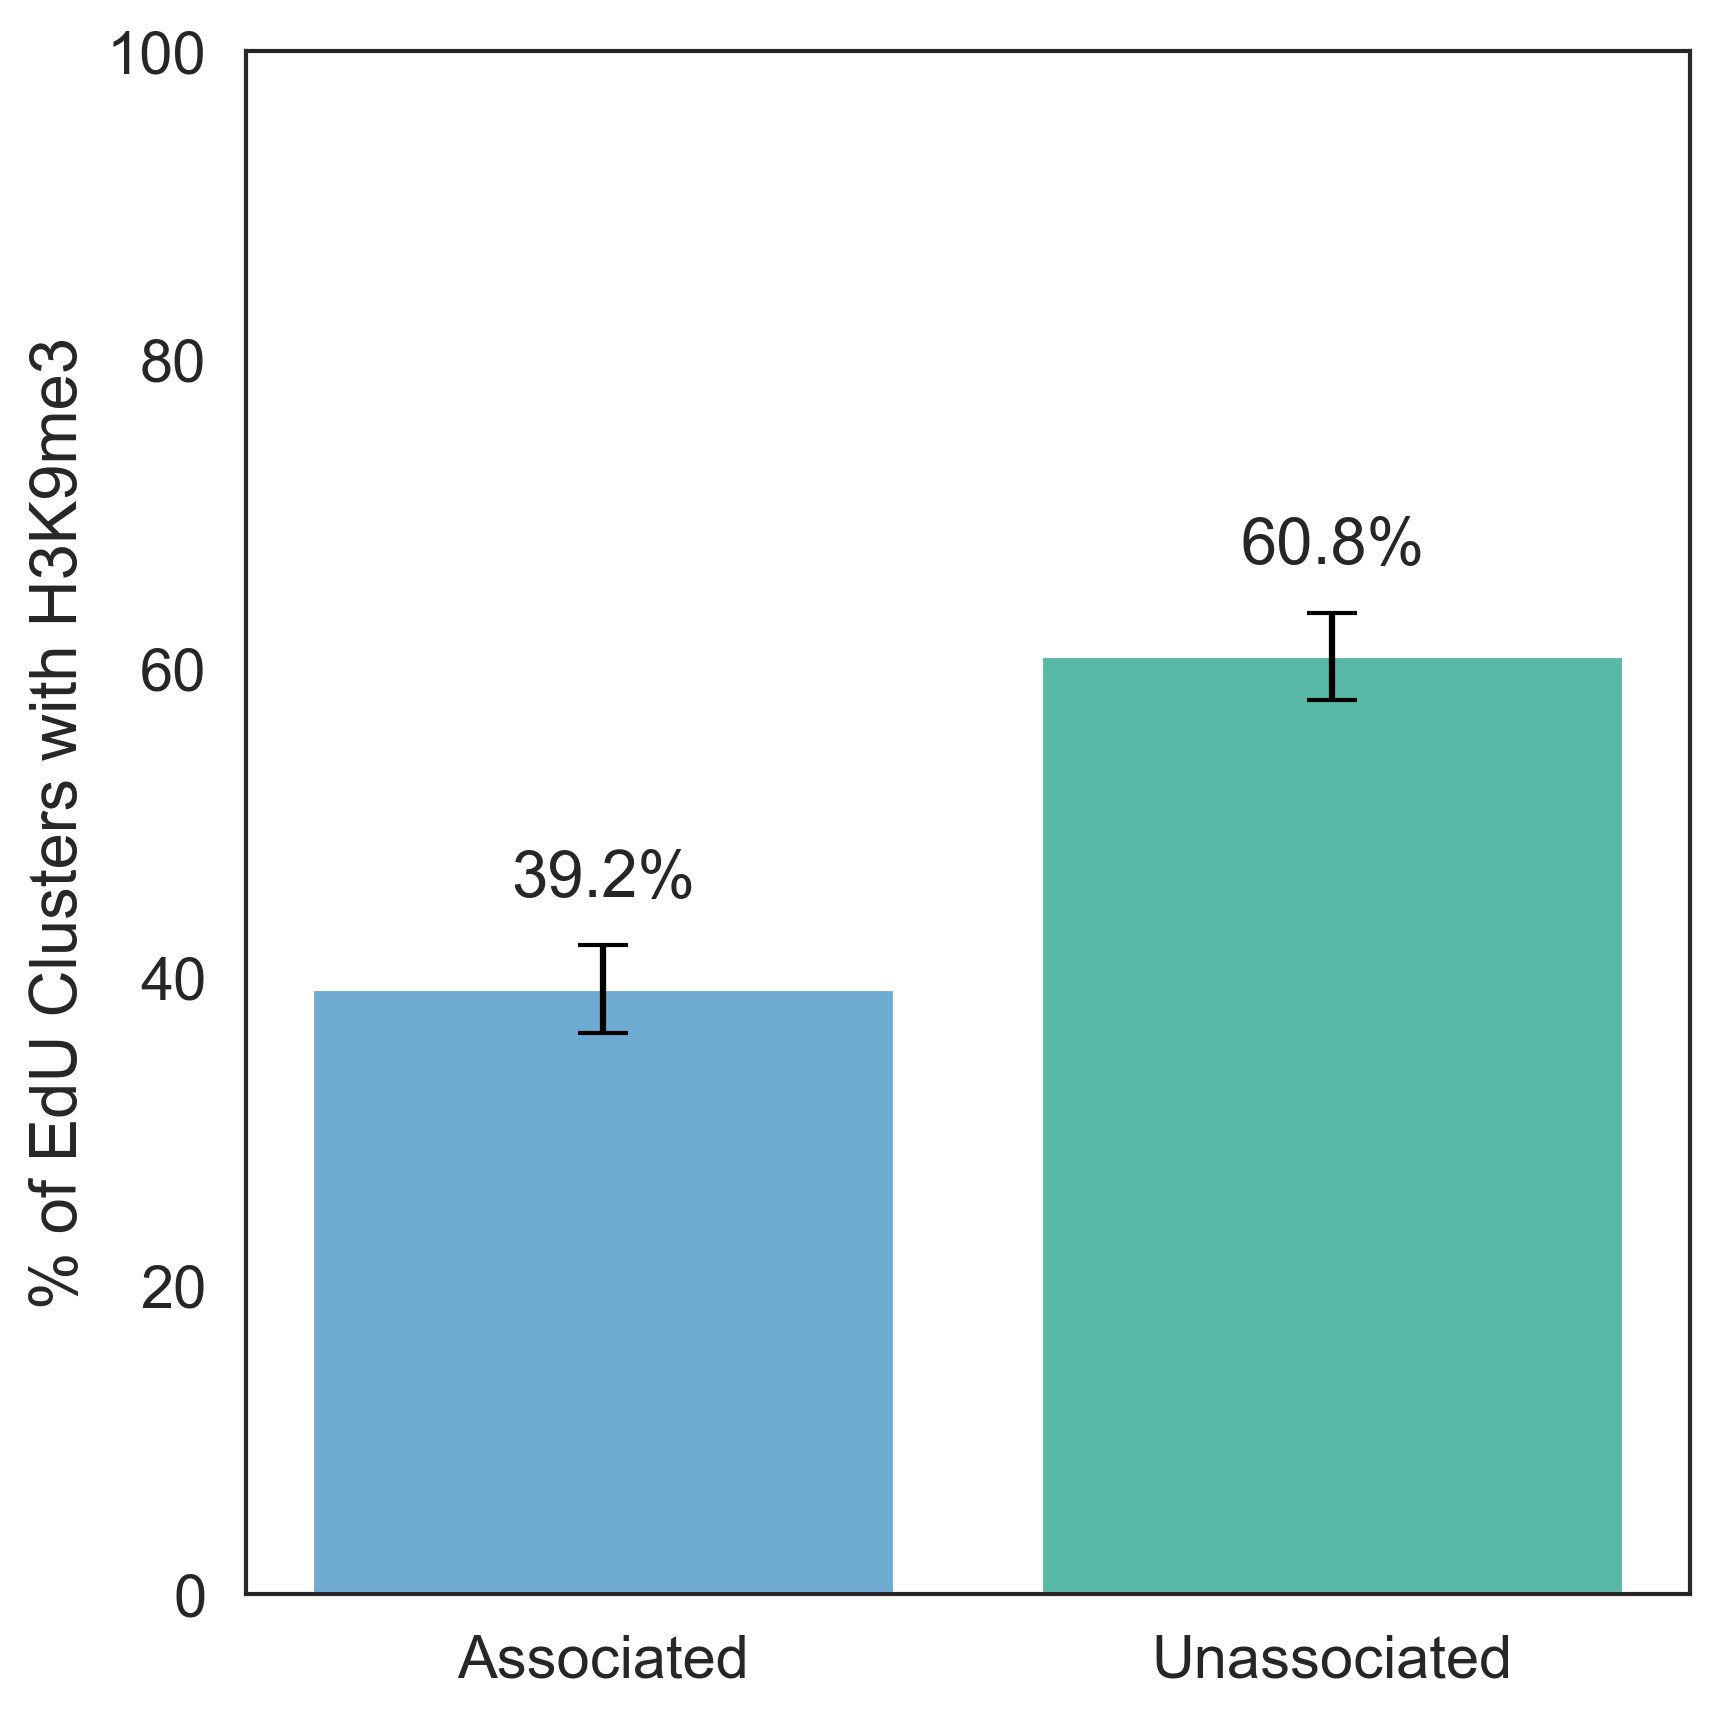

AUXIN ONLY
Associated: 39.19% (95% Wilson CI: 36.40–42.06%)
Unassociated: 60.81% (95% Wilson CI: 57.94–63.60%)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint
import matplotlib.ticker as mtick 

# =============================
# LOAD DATA
# =============================
df = pd.read_csv(r"C:\Users\tkx1376\Downloads\EdU_Concat_withAssociationData_reformat4Plotting_v1.csv")

# =============================
# HANDLE MISSING VALUES
# =============================
df['Auxin Association'] = df['Auxin Association'].fillna(0)

# =============================
# COUNTS
# =============================
auxin_total = len(df['Auxin Association'])

auxin_assoc = (df['Auxin Association'] == 1).sum()
auxin_non   = (df['Auxin Association'] != 1).sum()

# =============================
# PERCENTAGES
# =============================
assoc_prop = auxin_assoc / auxin_total
non_prop   = auxin_non / auxin_total

assoc_pct = assoc_prop * 100
non_pct   = non_prop * 100

# =============================
# WILSON 95% CONFIDENCE INTERVALS
# =============================
assoc_low, assoc_high = proportion_confint(
    auxin_assoc,
    auxin_total,
    alpha=0.05,
    method='wilson'
)

non_low, non_high = proportion_confint(
    auxin_non,
    auxin_total,
    alpha=0.05,
    method='wilson'
)

# Convert to percentages
assoc_low *= 100
assoc_high *= 100
non_low *= 100
non_high *= 100

# Error bar distances from mean
assoc_err = [[assoc_pct - assoc_low],
             [assoc_high - assoc_pct]]

non_err = [[non_pct - non_low],
           [non_high - non_pct]]

# =============================
# PREP DATA
# =============================
plot_df = pd.DataFrame({
    'Category': ['Associated', 'Unassociated'],
    'Percentage': [assoc_pct, non_pct]
})

# =============================
# PLOT
# =============================
sns.set(style="white", font_scale=1.3)
plt.figure(figsize=(6, 6))

colors = ['#5DADE2', '#48C9B0']

ax = sns.barplot(
    data=plot_df,
    x='Category',
    y='Percentage',
    palette=colors,
)

# Add Wilson CI error bars
ax.errorbar(
    x=[0, 1],
    y=[assoc_pct, non_pct],
    yerr=[
        [assoc_pct - assoc_low, non_pct - non_low],      # lower
        [assoc_high - assoc_pct, non_high - non_pct]     # upper
    ],
    fmt='none',
    ecolor='black',
    capsize=6,
    linewidth=1.5
)

# =============================
# STYLE
# =============================
plt.title(
    '',
    fontsize=16,
    weight='bold'
)

plt.ylabel('% of EdU Clusters with H3K9me3')
plt.xlabel('')
plt.ylim(0, 100)

# Add percentage labels
for i, row in plot_df.iterrows():
    ax.text(
        i,
        row['Percentage'] + 6,
        f"{row['Percentage']:.1f}%",
        ha='center'
    )

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)

ax.grid(False)

plt.tight_layout()
plt.show()

# =============================
# PRINT RESULTS
# =============================
print(f"Associated: {assoc_pct:.2f}% "
      f"(95% Wilson CI: {assoc_low:.2f}–{assoc_high:.2f}%)")

print(f"Unassociated: {non_pct:.2f}% "
      f"(95% Wilson CI: {non_low:.2f}–{non_high:.2f}%)")